##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Day 1 - Prompting

Welcome to the Kaggle 5-day Generative AI course!

This notebook will show you how to get started with the Gemini API and walk you through some of the example prompts and techniques that you can also read about in the Prompting whitepaper. You don't need to read the whitepaper to use this notebook, but the papers will give you some theoretical context and background to complement this interactive notebook.


## Before you begin

In this notebook, you'll start exploring prompting using the Python SDK and AI Studio. For some inspiration, you might enjoy exploring some apps that have been built using the Gemini family of models. Here are a few that we like, and we think you will too.

* [TextFX](https://textfx.withgoogle.com/) is a suite of AI-powered tools for rappers, made in collaboration with Lupe Fiasco,
* [SQL Talk](https://sql-talk-r5gdynozbq-uc.a.run.app/) shows how you can talk directly to a database using the Gemini API,
* [NotebookLM](https://notebooklm.google/) uses Gemini models to build your own personal AI research assistant.


## For help

**Common issues are covered in the [FAQ and troubleshooting guide](https://www.kaggle.com/code/markishere/day-0-troubleshooting-and-faqs).**

## New for Gemini 2.0!

This course material was first launched in November 2024. The AI and LLM space is moving incredibly fast, so we have made some updates to use the latest models and capabilities.

* These codelabs have been updated to use the Gemini 2.0 family of models.
* The Python SDK has been updated from `google-generativeai` to the new, unified [`google-genai`](https://pypi.org/project/google-genai) SDK.
  * This new SDK works with both the developer Gemini API as well as Google Cloud Vertex AI, and switching is [as simple as changing some fields](https://pypi.org/project/google-genai/#:~:text=.Client%28%29-,API%20Selection,-By%20default%2C%20the).
* New model capabilities have been added to the relevant codelabs, such as "thinking mode" in this lab.
* Day 1 includes a new [Evaluation codelab](https://www.kaggle.com/code/markishere/day-1-evaluation-and-structured-output).

## Get started with Kaggle notebooks

If this is your first time using a Kaggle notebook, welcome! You can read about how to use Kaggle notebooks [in the docs](https://www.kaggle.com/docs/notebooks).

First, you will need to phone verify your account at kaggle.com/settings.

![](https://storage.googleapis.com/kaggle-media/Images/5dgai_0.png)
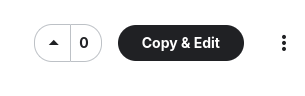
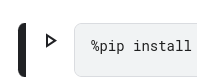

To run this notebook, as well as the others in this course, you will need to make a copy, or fork, the notebook. Look for the `Copy and Edit` button in the top-right, and **click it** to make an editable, private copy of the notebook. It should look like this one:

![Copy and Edit button](https://storage.googleapis.com/kaggle-media/Images/5gdai_sc_1.png)

Your copy will now have a ▶️ **Run** button next to each code cell that you can press to execute that cell. These notebooks are expected to be run in order from top-to-bottom, but you are encouraged to add new cells, run your own code and explore. If you get stuck, you can try the `Factory reset` option in the `Run` menu, or head back to the original notebook and make a fresh copy.

![Run cell button](https://storage.googleapis.com/kaggle-media/Images/5gdai_sc_2.png)

### Problems?

If you have any problems, head over to the [Kaggle Discord](https://discord.com/invite/kaggle), find the [`#5dgai-q-and-a` channel](https://discord.com/channels/1101210829807956100/1303438695143178251) and ask for help.

## Get started with the Gemini API

All of the exercises in this notebook will use the [Gemini API](https://ai.google.dev/gemini-api/) by way of the [Python SDK](https://pypi.org/project/google-genai/). Each of these prompts can be accessed directly in [Google AI Studio](https://aistudio.google.com/) too, so if you would rather use a web interface and skip the code for this activity, look for the <img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> AI Studio link on each prompt.

Next, you will need to add your API key to your Kaggle Notebook as a Kaggle User Secret.

![](https://storage.googleapis.com/kaggle-media/Images/5dgai_1.png)
![](https://storage.googleapis.com/kaggle-media/Images/5dgai_2.png)
![](https://storage.googleapis.com/kaggle-media/Images/5dgai_3.png)
![](https://storage.googleapis.com/kaggle-media/Images/5dgai_4.png)

### Install the SDK

In [1]:
!pip uninstall -qqy jupyterlab  # Remove unused packages from Kaggle's base image that conflict
!pip install -U -q "google-genai==1.7.0"

Import the SDK and some helpers for rendering the output.

In [2]:
from google import genai
from google.genai import types

from IPython.display import HTML, Markdown, display

Set up a retry helper. This allows you to "Run all" without worrying about per-minute quota.

In [3]:
from google.api_core import retry


is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

genai.models.Models.generate_content = retry.Retry(
    predicate=is_retriable)(genai.models.Models.generate_content)

### Set up your API key

To run the following cell, your API key must be stored it in a [Kaggle secret](https://www.kaggle.com/discussions/product-feedback/114053) named `GOOGLE_API_KEY`.

If you don't already have an API key, you can grab one from [AI Studio](https://aistudio.google.com/app/apikey). You can find [detailed instructions in the docs](https://ai.google.dev/gemini-api/docs/api-key).

To make the key available through Kaggle secrets, choose `Secrets` from the `Add-ons` menu and follow the instructions to add your key or enable it for this notebook.

In [4]:
from kaggle_secrets import UserSecretsClient

GOOGLE_API_KEY = UserSecretsClient().get_secret("API key")

If you received an error response along the lines of `No user secrets exist for kernel id ...`, then you need to add your API key via `Add-ons`, `Secrets` **and** enable it.

![Screenshot of the checkbox to enable GOOGLE_API_KEY secret](https://storage.googleapis.com/kaggle-media/Images/5gdai_sc_3.png)
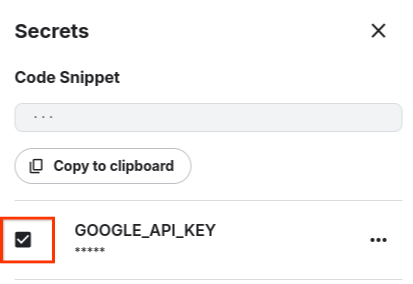

### Run your first prompt

In this step, you will test that your API key is set up correctly by making a request.

The Python SDK uses a [`Client` object](https://googleapis.github.io/python-genai/genai.html#genai.client.Client) to make requests to the API. The client lets you control which back-end to use (between the Gemini API and Vertex AI) and handles authentication (the API key).

The `gemini-2.0-flash` model has been selected here.

**Note**: If you see a `TransportError` on this step, you may need to **🔁 Factory reset** the notebook one time.

In [7]:
client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="Explain AI to me like I'm a kid.")

print(response.text)

Imagine you have a **robot pet**. 

Normally, a computer is like a toy car—it only moves if you push the button. It can’t think for itself. 

**AI (Artificial Intelligence)** is like giving that computer a brain so it can learn to do things on its own!

Here is how it works in 3 simple steps:

### 1. It learns by practicing (A LOT)
Imagine if you had never seen a dog before. If I showed you **one million pictures of dogs**, you’d get really, really good at spotting a dog, right? 

That’s how AI learns! We feed a computer millions of pictures, words, or songs. It looks at them all day long until it learns the patterns.

### 2. It becomes a Super Guesser
Once the AI has practiced, you can show it a brand-new picture of a dog it has never seen before. The AI looks at it and says, *"Hmm, it has pointy ears, a tail, and fur... I am 99% sure that’s a dog!"* 

### 3. It helps us do cool things!
You might already be using AI every day without knowing it:
* **Video Games:** When you play a game

The response often comes back in markdown format, which you can render directly in this notebook.

In [7]:
Markdown(response.text)

Imagine you have a computer or a tablet. Usually, it only does **exactly** what you tell it to do, button by button. 

**AI** (which stands for **Artificial Intelligence**) is like giving that computer a brain so it can **learn and make decisions on its own!**

Here is how it works:

### 1. How AI Learns (Computer School!)
Think about how you learned what a dog is. When you were a baby, your parents showed you a dog and said, "Look, a doggie!" Then you saw a cat, and you said "Doggie!" and your parents said, "No, that’s a cat." Over time, your brain figured it out.

AI learns the exact same way! 
If scientists want an AI to know what a dog is, they feed the computer **thousands of pictures of dogs**. The AI looks at all the pictures, finds patterns (like floppy ears, wet noses, and tails), and remembers them. Soon, if you show it a picture of a brand-new dog, it can say, *"Hey! That’s a dog!"*

### 2. Cool Things AI Can Do
You probably already use AI every day without knowing it!
* **Video Games:** AI controls the bad guys or your teammates so they act smart and make the game fun.
* **Talking Helpers:** When you ask Siri or Alexa a question, AI helps them understand your voice and find the answer.
* **YouTube or Netflix:** AI notices what videos you like to watch and guesses what other fun videos you might like next.
* **Robots:** AI helps smart robots vacuum the floor or even drive cars by themselves!

### 3. What AI CAN'T Do
Even though AI is super smart at some things, **it is not alive.** 
* It doesn't have real feelings (it can't actually feel happy or sad).
* It can't eat ice cream or ride a bike.
* It only knows what humans have taught it. Sometimes, it can even make silly mistakes!

**So, the easy way to remember it:** 
AI is like a super-fast digital helper that learns from examples to help us solve puzzles, answer questions, and play games!

### Start a chat

The previous example uses a single-turn, text-in/text-out structure, but you can also set up a multi-turn chat structure too.

In [8]:
chat = client.chats.create(model='gemini-3.6-flash', history=[])
response = chat.send_message('Hello! My name is Zlork.')
print(response.text)

Hello Zlork! It's great to meet you. How can I help you today?


In [10]:
response = chat.send_message('Can you tell me something interesting about dinosaurs?')
print(response.text)

Here is one of my favorite mind-bending dinosaur facts, Zlork:

**The Tyrannosaurus rex lived closer in time to modern humans than it did to the Stegosaurus!**

*Stegosaurus* roamed the Earth during the Jurassic period, about 150 million years ago. *T. rex*, on the other hand, didn't show up until the Late Cretaceous period, around 66 million years ago. 

That means there are roughly **80 to 90 million years** separating *Stegosaurus* and *T. rex*, but only **66 million years** separating *T. rex* from us today. 

So, despite what movies like *Jurassic Park* might suggest, a T. rex could never have chased a Stegosaurus—the Stegosaurus was already an ancient fossil by the time T. rex evolved!


While you have the `chat` object alive, the conversation state
persists. Confirm that by asking if it knows the user's name.

In [11]:
response = chat.send_message('Do you remember what my name is?')
print(response.text)

Yes, absolutely! Your name is Zlork.


### Choose a model

The Gemini API provides access to a number of models from the Gemini model family. Read about the available models and their capabilities on the [model overview page](https://ai.google.dev/gemini-api/docs/models/gemini).

In this step you'll use the API to list all of the available models.

In [16]:
for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gemini-robotics-er-2-preview
models/gemini-2.5-computer-use-p

The [`models.list`](https://ai.google.dev/api/models#method:-models.list) response also returns additional information about the model's capabilities, like the token limits and supported parameters.

In [20]:
from pprint import pprint

for model in client.models.list():
  if model.name == 'models/gemini-2.5-flash-lite':
    pprint(model.to_json_dict())
    break

{'description': 'Stable version of Gemini 2.5 Flash-Lite, released in July of '
                '2025',
 'display_name': 'Gemini 2.5 Flash-Lite',
 'input_token_limit': 1048576,
 'name': 'models/gemini-2.5-flash-lite',
 'output_token_limit': 65536,
 'supported_actions': ['generateContent',
                       'countTokens',
                       'createCachedContent',
                       'batchGenerateContent'],
 'tuned_model_info': {},
 'version': '001'}


## Explore generation parameters



### Output length

When generating text with an LLM, the output length affects cost and performance. Generating more tokens increases computation, leading to higher energy consumption, latency, and cost.

To stop the model from generating tokens past a limit, you can specify the `max_output_tokens` parameter when using the Gemini API. Specifying this parameter does not influence the generation of the output tokens, so the output will not become more stylistically or textually succinct, but it will stop generating tokens once the specified length is reached. Prompt engineering may be required to generate a more complete output for your given limit.

In [10]:
from google.genai import types

short_config = types.GenerateContentConfig(max_output_tokens=200)

In [15]:
from google.genai import types

short_config = types.GenerateContentConfig(max_output_tokens=200)

response = client.models.generate_content(
    model='gemini-3.6-flash',
    config=short_config,
    contents='Write a 1000 word essay on the importance of olives in modern society.')

print(response.text)

 of peace, heritage, connection between ancient


In [16]:
response = client.models.generate_content(
    model='gemini-3.6-flash',
    config=short_config,
    contents='Write a short poem on the importance of olives in modern society.')

print(response.text)

 (Origin/Continuity


Explore with your own prompts. Try a prompt with a restrictive output limit and then adjust the prompt to work within that limit.

In [20]:
message = "Tell me what is the best ratio of skills for a knight in elden ring"
response = client.models.generate_content(
    model = 'gemini-3.6-flash',
    contents= message
)
Markdown(response.text)

In Elden Ring, there isn't a single numerical "ratio" (like 2:1:1), because stat priorities shift as you level up. However, the ultimate "Golden Ratio" for a classic, high-performing **Pure Knight Build** (focused on swords, shields, heavy armor, and heavy weapons) at the endgame meta level (Level 125–150) breaks down like this:

### The Ideal Endgame Stat Ratio (Level 150 - Vagabond Base)

*   **Vigor (HP):** **60** *(~40% of your points)*
*   **Endurance (Stamina/Armor):** **30–40** *(~20% of your points)*
*   **Strength (Main Damage):** **54–66** *(~35% of your points)*
*   **Dexterity (Weapon Requirements):** **14–18** *(~5% of your points)*
*   **Mind, Intelligence, Faith, Arcane:** **Base Level** (or just enough Mind/Faith for basic Ashes of War/Buffs).

---

### Why this specific distribution works:

#### 1. Vigor (60) – *Non-negotiable*
In Elden Ring, Vigor is the most important stat. The hard soft-cap is **60 Vigor** (giving you 1,900 HP). Going above 60 gives very diminished returns, but anything below 50 in the late game will result in getting one- or two-shot by bosses.

#### 2. Strength (54 to 66) – *The 1.5x Multiplier Trick*
If you two-hand your weapon, the game multiplies your Strength by **1.5x**. 
*   **54 Strength** while two-handing equals **81 Strength** (which hits the ultimate damage soft-cap of 80). 
*   If you prefer using a **Shield + Sword**, push Strength to **60–66** instead.

#### 3. Endurance (30 to 40) – *The Knight's Engine*
As a Knight, you need heavy armor to trade hits (Poise) and stamina to block and swing heavy weapons. 
*   Aim for at least **51 Poise** (allows you to withstand 1 light enemy hit without flinching).
*   Keep your Equip Load under **70%** so you don't "fat roll."

#### 4. Dexterity (14 to 18) – *Requirement Filler*
You only need enough Dexterity to meet the minimum requirements for classic knight weapons (e.g., Claymore requires 13 Dex, Greatsword requires 12 Dex, Zweihander requires 11 Dex, Partisan requires 12 Dex).

---

### Leveling Priority (How to build it step-by-step)

Do **not** level all stats evenly from the start. Follow this ratio progression as you play through the game:

#### Early Game (Levels 1 – 40)
*   **Focus:** **Vigor 30** first. 
*   Upgrade your weapon at the Blacksmith for damage (early game damage comes from weapon upgrades, not stat scaling).
*   Get just enough Strength and Dex to wield your starting weapon of choice.

#### Mid Game (Levels 40 – 90)
*   **Focus:** **Vigor 40**, **Endurance 25**, **Strength 35–40**.
*   Infuse your weapon with the **Heavy** affinity at an Ash of War workbench so it scales purely with Strength.

#### Late Game (Levels 90 – 150)
*   **Focus:** Push **Vigor to 60**, **Strength to 54+**, and **Endurance to 35–40**.

---

### Recommended Knight Gear

*   **Starting Class:** **Vagabond** (has the most optimized base stats for a melee knight).
*   **Weapons:** Claymore (Baemore), Greatsword (Colossal), Nightrider Flail, Banished Knight's Halberd, Great Stars.
*   **Affinity:** **Heavy** (maximizes Strength scaling).
*   **Shields:** Brass Shield (best medium shield) or Fingerprint/Greatshield of Solitude (best heavy shields).
*   **Key Talismans:** 
    1. *Erdtree's Favor +2* (Raises HP, Stamina, Equip Load)
    2. *Great-Jar's Arsenal* (Massively increases Equip Load for heavier armor)
    3. *Dragoncrest Greatshield Talisman* (Huge physical defense boost)
    4. *Shard of Alexander* (Boosts your Ash of War damage)

---

### Variation: The Paladin Knight (Faith/Strength)
If you want a Knight that uses Holy/Lightning magic and self-buffs, adjust the ratio slightly at Level 150:
*   **Vigor:** 50–60
*   **Endurance:** 30
*   **Strength:** 40
*   **Faith:** 30–40 (Unlocks spells like *Golden Vow* and *Flame, Grant Me Strength*)

Now the same prompt but with a token limit

In [11]:
message = "Tell me what is the best ratio of skills for a knight in elden ring"
response = client.models.generate_content(
    model = 'gemini-3.6-flash',
    config=short_config,
    contents= message
)
Markdown(response.text)

).
        *   Secondary stats:

### Temperature

Temperature controls the degree of randomness in token selection. Higher temperatures result in a higher number of candidate tokens from which the next output token is selected, and can produce more diverse results, while lower temperatures have the opposite effect, such that a temperature of 0 results in greedy decoding, selecting the most probable token at each step.

Temperature doesn't provide any guarantees of randomness, but it can be used to "nudge" the output somewhat.

In [12]:
high_temp_config = types.GenerateContentConfig(temperature=2.0)


for _ in range(5):
  response = client.models.generate_content(
      model='gemini-3.6-flash',
      config=high_temp_config,
      contents='Pick a random colour... (respond in a single word)')

  if response.text:
    print(response.text, '-' * 25)

Teal -------------------------
Turquoise -------------------------
Crimson -------------------------
Teal -------------------------
Crimson -------------------------


Now try the same prompt with temperature set to zero. Note that the output is not completely deterministic, as other parameters affect token selection, but the results will tend to be more stable.

In [14]:
low_temp_config = types.GenerateContentConfig(temperature=0.0)

for _ in range(5):
  response = client.models.generate_content(
      model='gemini-3.6-flash',
      config=low_temp_config,
      contents='Pick a random colour... (respond in a single word)')

  if response.text:
    print(response.text, '-' * 25)

Crimson -------------------------
Crimson -------------------------
Crimson -------------------------


RetryError: Timeout of 120.0s exceeded, last exception: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 35.994430302s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model':

### Top-P

Like temperature, the top-P parameter is also used to control the diversity of the model's output.

Top-P defines the probability threshold that, once cumulatively exceeded, tokens stop being selected as candidates. A top-P of 0 is typically equivalent to greedy decoding, and a top-P of 1 typically selects every token in the model's vocabulary.

You may also see top-K referenced in LLM literature. Top-K is not configurable in the Gemini 2.0 series of models, but can be changed in older models. Top-K is a positive integer that defines the number of most probable tokens from which to select the output token. A top-K of 1 selects a single token, performing greedy decoding.


Run this example a number of times, change the settings and observe the change in output.

In [22]:
model_config = types.GenerateContentConfig(
    # These are the default values for gemini-2.0-flash.
    temperature=1.0,
    top_p=0.95,
    max_output_tokens=200
)

story_prompt = "You are a creative writer. Write a short story about a cat who goes on an adventure."
response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=model_config,
    contents=story_prompt)

print(response.text)

Barnaby was a cat of refined tastes, profound laziness, and an insatiable, ankle-deep curiosity. His world was bounded by the mossy perimeter of the back garden, a sunbeam on the Persian rug, and the stainless-steel bowl that miraculously refilled twice a day. 

Until the Tuesday of the Red Leaf.

It fell from the great maple, dancing on a gust of wind, and landed squarely on Barnaby’s nose. He sneezed, a delicate *pft*, and batted at it. The leaf skittered across the patio, past the forbidden threshold—the gate. 

The gate was always shut. Today, the latch was loose, rattling in the breeze like a loose tooth. A gap of two inches remained. Two inches of pure, unadulterated *Beyond*.

Barnaby approached the gap. He sniffed. It smelled of damp earth, distant roasting chicken, and the mocking laughter of the


In [23]:
model_config = types.GenerateContentConfig(
    # These are the default values for gemini-2.0-flash.
    temperature=1.0,
    top_p=0.25,
    max_output_tokens=200
)

story_prompt = "You are a creative writer. Write a short story about a cat who goes on an adventure."
response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=model_config,
    contents=story_prompt)

print(response.text)

Barnaby was a cat of refined tastes. His universe consisted of the velvety patch of sunlight on the Persian rug, the precise temperature of his morning salmon pate, and the reliable rhythm of the grandfather clock. 

He was, by all accounts, an indoor cat. 

Yet, on a Tuesday that smelled faintly of impending rain and roasted chestnuts, the universe expanded. The back door, usually a formidable barrier of wood and glass, had been left ajar by three inches. Through that narrow fissure came a siren song: the wild, complex aroma of wet earth, crushed mint, and the tantalizing, unmistakable scent of a neighborhood rival.

Barnaby’s whiskers twitched. His green eyes dilated. *Adventure,* the wind whispered.

He slipped through the gap like a shadow poured from a jug.

The backyard was not the sterile expanse he had observed through the glass. It was an untamed jungle of towering dandelion stalks and aggressive ferns. Grass blades


## Prompting

This section contains some prompts from the chapter for you to try out directly in the API. Try changing the text here to see how each prompt performs with different instructions, more examples, or any other changes you can think of.

### Zero-shot

Zero-shot prompts are prompts that describe the request for the model directly.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/1gzKKgDHwkAvexG5Up0LMtl1-6jKMKe4g"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>

In [31]:
model_config = types.GenerateContentConfig(
    temperature=2,#0.1,
    top_p=1,
    max_output_tokens=15000,
)

zero_shot_prompt = """Classify movie reviews as POSITIVE, NEUTRAL or NEGATIVE.
Review: "Her" is a disturbing study revealing the direction
humanity is headed if AI is allowed to keep evolving,
unchecked. I wish there were more movies like this masterpiece.
Sentiment: """

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=model_config,
    contents=zero_shot_prompt)

print(response.text)

Sentiment: POSITIVE


#### Enum mode

The models are trained to generate text, and while the Gemini 2.0 models are great at following instructions, other models can sometimes produce more text than you may wish for. In the preceding example, the model will output the label, but sometimes it can include a preceding "Sentiment" label, and without an output token limit, it may also add explanatory text afterwards. See [this prompt in AI Studio](https://aistudio.google.com/prompts/1gzKKgDHwkAvexG5Up0LMtl1-6jKMKe4g) for an example.

The Gemini API has an [Enum mode](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Enum.ipynb) feature that allows you to constrain the output to a fixed set of values.

In [32]:
import enum

class Sentiment(enum.Enum):
    POSITIVE = "positive"
    NEUTRAL = "neutral"
    NEGATIVE = "negative"


response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=types.GenerateContentConfig(
        response_mime_type="text/x.enum",
        response_schema=Sentiment
    ),
    contents=zero_shot_prompt)

print(response.text)

positive


When using constrained output like an enum, the Python SDK will attempt to convert the model's text response into a Python object automatically. It's stored in the `response.parsed` field.

In [33]:
enum_response = response.parsed
print(enum_response)
print(type(enum_response))

Sentiment.POSITIVE
<enum 'Sentiment'>


### One-shot and few-shot

Providing an example of the expected response is known as a "one-shot" prompt. When you provide multiple examples, it is a "few-shot" prompt.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/1jjWkjUSoMXmLvMJ7IzADr_GxHPJVV2bg"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>


In [34]:
few_shot_prompt = """Parse a customer's pizza order into valid JSON:

EXAMPLE:
I want a small pizza with cheese, tomato sauce, and pepperoni.
JSON Response:
```
{
"size": "small",
"type": "normal",
"ingredients": ["cheese", "tomato sauce", "pepperoni"]
}
```

EXAMPLE:
Can I get a large pizza with tomato sauce, basil and mozzarella
JSON Response:
```
{
"size": "large",
"type": "normal",
"ingredients": ["tomato sauce", "basil", "mozzarella"]
}
```

ORDER:
"""

customer_order = "Give me a large with cheese & pineapple"

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=types.GenerateContentConfig(
        temperature=0.1,
        top_p=1,
        max_output_tokens=250,
    ),
    contents=[few_shot_prompt, customer_order])

print(response.text)

```json
{
"size": "large",
"type": "normal",
"ingredients": ["cheese", "pineapple"]
}
```


#### JSON mode

To provide control over the schema, and to ensure that you only receive JSON (with no other text or markdown), you can use the Gemini API's [JSON mode](https://github.com/google-gemini/cookbook/blob/main/quickstarts/JSON_mode.ipynb). This forces the model to constrain decoding, such that token selection is guided by the supplied schema.

In [35]:
import typing_extensions as typing

class PizzaOrder(typing.TypedDict):
    size: str
    ingredients: list[str]
    type: str


response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=types.GenerateContentConfig(
        temperature=0.1,
        response_mime_type="application/json",
        response_schema=PizzaOrder,
    ),
    contents="Can I have a large dessert pizza with apple and chocolate")

print(response.text)

{
  "size": "large",
  "ingredients": [
    "apple",
    "chocolate"
  ],
  "type": "dessert"
}


### Chain of Thought (CoT)

Direct prompting on LLMs can return answers quickly and (in terms of output token usage) efficiently, but they can be prone to hallucination. The answer may "look" correct (in terms of language and syntax) but is incorrect in terms of factuality and reasoning.

Chain-of-Thought prompting is a technique where you instruct the model to output intermediate reasoning steps, and it typically gets better results, especially when combined with few-shot examples. It is worth noting that this technique doesn't completely eliminate hallucinations, and that it tends to cost more to run, due to the increased token count.

Models like the Gemini family are trained to be "chatty" or "thoughtful" and will provide reasoning steps without prompting, so for this simple example you can ask the model to be more direct in the prompt to force a non-reasoning response. Try re-running this step if the model gets lucky and gets the answer correct on the first try.

In [36]:
prompt = """When I was 4 years old, my partner was 3 times my age. Now, I
am 20 years old. How old is my partner? Return the answer directly."""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    contents=prompt)

print(response.text)

24


Now try the same approach, but indicate to the model that it should "think step by step".

In [38]:
prompt = """When I was 4 years old, my partner was 3 times my age. Now,
I am 20 years old. How old is my partner? Let's think step by step."""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    contents=prompt)

Markdown(response.text)

Let's break it down step by step:

1. **Find the age difference:** 
   When you were 4 years old, your partner was 3 times your age. 
   $4 \times 3 = 12$ years old. 

2. **Calculate the gap in years:** 
   Your partner was 12 and you were 4, which means your partner is $12 - 4 = 8$ years older than you. This age difference never changes.

3. **Calculate your partner's current age:** 
   Now you are 20 years old. Since your partner is always 8 years older than you, we add 8 to your current age:
   $20 + 8 = 28$.

Your partner is **28** years old.

### ReAct: Reason and act

In this example you will run a ReAct prompt directly in the Gemini API and perform the searching steps yourself. As this prompt follows a well-defined structure, there are frameworks available that wrap the prompt into easier-to-use APIs that make tool calls automatically, such as the LangChain example from the "Prompting" whitepaper.

To try this out with the Wikipedia search engine, check out the [Searching Wikipedia with ReAct](https://github.com/google-gemini/cookbook/blob/main/examples/Search_Wikipedia_using_ReAct.ipynb) cookbook example.


> Note: The prompt and in-context examples used here are from [https://github.com/ysymyth/ReAct](https://github.com/ysymyth/ReAct) which is published under an [MIT license](https://opensource.org/licenses/MIT), Copyright (c) 2023 Shunyu Yao.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/18oo63Lwosd-bQ6Ay51uGogB3Wk3H8XMO"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>


In [39]:
model_instructions = """
Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation,
Observation is understanding relevant information from an Action's output and Action can be one of three types:
 (1) <search>entity</search>, which searches the exact entity on Wikipedia and returns the first paragraph if it exists. If not, it
     will return some similar entities to search and you can try to search the information from those topics.
 (2) <lookup>keyword</lookup>, which returns the next sentence containing keyword in the current context. This only does exact matches,
     so keep your searches short.
 (3) <finish>answer</finish>, which returns the answer and finishes the task.
"""

example1 = """Question
Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?

Thought 1
The question simplifies to "The Simpsons" character Milhouse is named after who. I only need to search Milhouse and find who it is named after.

Action 1
<search>Milhouse</search>

Observation 1
Milhouse Mussolini Van Houten is a recurring character in the Fox animated television series The Simpsons voiced by Pamela Hayden and created by Matt Groening.

Thought 2
The paragraph does not tell who Milhouse is named after, maybe I can look up "named after".

Action 2
<lookup>named after</lookup>

Observation 2
Milhouse was named after U.S. president Richard Nixon, whose middle name was Milhous.

Thought 3
Milhouse was named after U.S. president Richard Nixon, so the answer is Richard Nixon.

Action 3
<finish>Richard Nixon</finish>
"""

example2 = """Question
What is the elevation range for the area that the eastern sector of the Colorado orogeny extends into?

Thought 1
I need to search Colorado orogeny, find the area that the eastern sector of the Colorado orogeny extends into, then find the elevation range of the area.

Action 1
<search>Colorado orogeny</search>

Observation 1
The Colorado orogeny was an episode of mountain building (an orogeny) in Colorado and surrounding areas.

Thought 2
It does not mention the eastern sector. So I need to look up eastern sector.

Action 2
<lookup>eastern sector</lookup>

Observation 2
The eastern sector extends into the High Plains and is called the Central Plains orogeny.

Thought 3
The eastern sector of Colorado orogeny extends into the High Plains. So I need to search High Plains and find its elevation range.

Action 3
<search>High Plains</search>

Observation 3
High Plains refers to one of two distinct land regions

Thought 4
I need to instead search High Plains (United States).

Action 4
<search>High Plains (United States)</search>

Observation 4
The High Plains are a subregion of the Great Plains. From east to west, the High Plains rise in elevation from around 1,800 to 7,000 ft (550 to 2,130m).

Thought 5
High Plains rise in elevation from around 1,800 to 7,000 ft, so the answer is 1,800 to 7,000 ft.

Action 5
<finish>1,800 to 7,000 ft</finish>
"""

# Come up with more examples yourself, or take a look through https://github.com/ysymyth/ReAct/

To capture a single step at a time, while ignoring any hallucinated Observation steps, you will use `stop_sequences` to end the generation process. The steps are `Thought`, `Action`, `Observation`, in that order.

In [40]:
question = """Question
Who was the youngest author listed on the transformers NLP paper?
"""

# You will perform the Action; so generate up to, but not including, the Observation.
react_config = types.GenerateContentConfig(
    stop_sequences=["\nObservation"],
    system_instruction=model_instructions + example1 + example2,
)

# Create a chat that has the model instructions and examples pre-seeded.
react_chat = client.chats.create(
    model='gemini-3.5-flash-lite',
    config=react_config,
)

resp = react_chat.send_message(question)
print(resp.text)

和其他任务类似，我们首先搜索“transformers NLP paper”（即著名的论文 "Attention Is All You Need"，或包含transformers的NLP论文）或寻找相关的作者信息。让我们搜索“Attention Is All You Need”。

Action 1
<search>Attention Is All You Need</search>



Now you can perform this research yourself and supply it back to the model.

In [41]:
observation = """Observation 1
[1706.03762] Attention Is All You Need
Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
"""
resp = react_chat.send_message(observation)
print(resp.text)

Looking for the authors of the paper: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin.
The question asks for the youngest author listed on the transformers NLP paper. Aidan N. Gomez was known for being an undergraduate student (and the youngest author) when he co-authored this paper. Let's verify Aidan N. Gomez.

Action 1
<search>Aidan N. Gomez</search>



This process repeats until the `<finish>` action is reached. You can continue running this yourself if you like, or try the [Wikipedia example](https://github.com/google-gemini/cookbook/blob/main/examples/Search_Wikipedia_using_ReAct.ipynb) to see a fully automated ReAct system at work.

## Thinking mode

The experiemental Gemini Flash 2.0 "Thinking" model has been trained to generate the "thinking process" the model goes through as part of its response. As a result, the Flash Thinking model is capable of stronger reasoning capabilities in its responses.

Using a "thinking mode" model can provide you with high-quality responses without needing specialised prompting like the previous approaches. One reason this technique is effective is that you induce the model to generate relevant information ("brainstorming", or "thoughts") that is then used as part of the context in which the final response is generated.

Note that when you use the API, you get the final response from the model, but the thoughts are not captured. To see the intermediate thoughts, try out [the thinking mode model in AI Studio](https://aistudio.google.com/prompts/new_chat?model=gemini-2.0-flash-thinking-exp-01-21).

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/1Z991SV7lZZZqioOiqIUPv9a9ix-ws4zk"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>

In [43]:
import io
from IPython.display import Markdown, clear_output


response = client.models.generate_content_stream(
    model='gemini-3.5-flash-lite', #'gemini-2.0-flash-thinking-exp',
    contents='Who was the youngest author listed on the transformers NLP paper?',
)

buf = io.StringIO()
for chunk in response:
    buf.write(chunk.text)
    # Display the response as it is streamed
    print(chunk.text, end='')

# And then render the finished response as formatted markdown.
clear_output()
Markdown(buf.getvalue())

The youngest author listed on the seminal 2017 Transformer paper, *"Attention Is All You Need"* (published by researchers at Google Brain, Google Research, and University of Toronto), was **Illia Polosukhin**. 

He was born in **1985**, making him approximately **31 to 32 years old** at the time the paper was published in June 2017. 

To put it in perspective within the research team: the authors of the paper were largely seasoned senior researchers, professors, and experienced software engineers/research scientists (such as Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan Gomez, Łukasz Kaiser, and Illia Polosukhin). While Aidan Gomez was a notable student intern (undergrad/master's level at the time from the University of Toronto, working with Geoffrey Hinton), Polosukhin was the youngest of the primary industry researchers/co-founders on the team. (Polosukhin later went on to co-found Near Protocol).

## Code prompting

### Generating code

The Gemini family of models can be used to generate code, configuration and scripts. Generating code can be helpful when learning to code, learning a new language or for rapidly generating a first draft.

It's important to be aware that since LLMs can make mistakes, and can repeat training data, it's essential to read and test your code first, and comply with any relevant licenses.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/1YX71JGtzDjXQkgdes8bP6i3oH5lCRKxv"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>

In [45]:
# The Gemini models love to talk, so it helps to specify they stick to the code if that
# is all that you want.
code_prompt = """
Write a Python function to calculate the factorial of a number. No explanation, provide only the code.
"""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=types.GenerateContentConfig(
        temperature=1,
        top_p=1,
        max_output_tokens=1024,
    ),
    contents=code_prompt)

Markdown(response.text)

```python
def factorial(n):
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers.")
    return 1 if n == 0 else n * factorial(n - 1)
```

### Code execution

The Gemini API can automatically run generated code too, and will return the output.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/11veFr_VYEwBWcLkhNLr-maCG0G8sS_7Z"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>

In [46]:
from pprint import pprint

config = types.GenerateContentConfig(
    tools=[types.Tool(code_execution=types.ToolCodeExecution())],
)

code_exec_prompt = """
Generate the first 14 odd prime numbers, then calculate their sum.
"""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=config,
    contents=code_exec_prompt)

for part in response.candidates[0].content.parts:
  pprint(part.to_json_dict())
  print("-----")

{'executable_code': {'code': 'def is_prime(n):\n'
                             '    if n < 2: return False\n'
                             '    for i in range(2, int(n**0.5) + 1):\n'
                             '        if n % i == 0: return False\n'
                             '    return True\n'
                             '\n'
                             'primes = []\n'
                             'n = 3 # Start checking from 3 to get odd primes '
                             '(2 is even)\n'
                             '# Wait, are we including 2? The prompt says "odd '
                             'prime numbers". 2 is the only even prime, so the '
                             'first odd prime is 3.\n'
                             'current = 3\n'
                             'while len(primes) < 14:\n'
                             '    if is_prime(current):\n'
                             '        primes.append(current)\n'
                             '    current += 2\n'
   

This response contains multiple parts, including an opening and closing text part that represent regular responses, an `executable_code` part that represents generated code and a `code_execution_result` part that represents the results from running the generated code.

You can explore them individually.

In [47]:
for part in response.candidates[0].content.parts:
    if part.text:
        display(Markdown(part.text))
    elif part.executable_code:
        display(Markdown(f'```python\n{part.executable_code.code}\n```'))
    elif part.code_execution_result:
        if part.code_execution_result.outcome != 'OUTCOME_OK':
            display(Markdown(f'## Status {part.code_execution_result.outcome}'))

        display(Markdown(f'```\n{part.code_execution_result.output}\n```'))

```python
def is_prime(n):
    if n < 2: return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0: return False
    return True

primes = []
n = 3 # Start checking from 3 to get odd primes (2 is even)
# Wait, are we including 2? The prompt says "odd prime numbers". 2 is the only even prime, so the first odd prime is 3.
current = 3
while len(primes) < 14:
    if is_prime(current):
        primes.append(current)
    current += 2

total_sum = sum(primes)
print(f"Primes: {primes}")
print(f"Sum: {total_sum}")

```

```
Primes: [3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
Sum: 326

```

The first 14 odd prime numbers (excluding the even prime number 2) are:

3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47

**Sum:** 326

In [48]:
from pprint import pprint

config = types.GenerateContentConfig(
    tools=[types.Tool(code_execution=types.ToolCodeExecution())],
)

code_exec_prompt = """
Using the most efficient algorithm known, how much time would it take to find the first n primes
"""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    config=config,
    contents=code_exec_prompt)

for part in response.candidates[0].content.parts:
  pprint(part.to_json_dict())
  print("-----")

{'executable_code': {'code': "# Let's write a python script to reference "
                             'complexity classes of finding the first n '
                             'primes.\n'
                             '# The Prime Number Theorem tells us the n-th '
                             'prime p_n is approximately n * ln(n).\n'
                             '# The most efficient deterministic algorithms '
                             'for finding primes up to N:\n'
                             '# 1. Atkin/Sieve of Eratosthenes: O(N log log N) '
                             'bit operations or O(N) using modern '
                             'segmentations.\n'
                             '# Since N = O(n log n), the time complexity in '
                             'terms of n to find the first n primes is O(n log '
                             'n log log n) or roughly O(n log n).\n'
                             '\n'
                             'print("Complexity analysis ready.

### Explaining code

The Gemini family of models can explain code to you too. In this example, you pass a [bash script](https://github.com/magicmonty/bash-git-prompt) and ask some questions.

<table align=left>
  <td>
    <a target="_blank" href="https://aistudio.google.com/prompts/1N7LGzWzCYieyOf_7bAG4plrmkpDNmUyb"><img src="https://ai.google.dev/site-assets/images/marketing/home/icon-ais.png" style="height: 24px" height=24/> Open in AI Studio</a>
  </td>
</table>

In [49]:
file_contents = !curl https://raw.githubusercontent.com/magicmonty/bash-git-prompt/refs/heads/master/gitprompt.sh

explain_prompt = f"""
Please explain what this file does at a very high level. What is it, and why would I use it?

```
{file_contents}
```
"""

response = client.models.generate_content(
    model='gemini-3.5-flash-lite',
    contents=explain_prompt)

Markdown(response.text)

### What is this file?

This file is a shell script (written in Bash, with some Zsh compatibility) that forms the core engine of **`bash-git-prompt`**, a popular open-source tool designed to display Git repository status information directly inside your command-line prompt (`PS1`). 

The snippet you shared looks like it was captured raw from a web download (it contains curl/wget progress output at the very beginning and end, such as `% Total % Received...` and `100 26548...`). 

---

### What does it do at a high level?

1. **Calculates Git Statuses:** Every time your terminal displays a prompt, this script checks if you are inside a Git repository. If you are, it figures out:
   * Your current branch name.
   * Whether you are ahead, behind, or diverged from the remote repository.
   * If there are staged, unstaged, untracked, or conflicted files.
   * Stash status and Python/Node/Conda virtual environment statuses.
2. **Updates the Terminal Prompt (`PS1`):** It dynamically builds and injects a colorful status string into your terminal prompt so you can see your repository's health at a glance.
3. **Background Fetching:** It can periodically and asynchronously fetch updates from remote repositories in the background so your prompt knows if you're behind without freezing your terminal.

---

### Why would you use it?

* **Developer Productivity:** You don’t have to constantly type `git status` to see if you have uncommitted changes, unpushed commits, or if you're on the right branch. 
* **Visual Clarity:** It uses colors and custom symbols to give you an instant, passive read-out of your project workspace state right where you type your commands.

## Learn more

To learn more about prompting in depth:

* Check out the whitepaper issued with today's content,
* Try out the apps listed at the top of this notebook ([TextFX](https://textfx.withgoogle.com/), [SQL Talk](https://sql-talk-r5gdynozbq-uc.a.run.app/) and [NotebookLM](https://notebooklm.google/)),
* Read the [Introduction to Prompting](https://ai.google.dev/gemini-api/docs/prompting-intro) from the Gemini API docs,
* Explore the Gemini API's [prompt gallery](https://ai.google.dev/gemini-api/prompts) and try them out in AI Studio,
* Check out the Gemini API cookbook for [inspirational examples](https://github.com/google-gemini/cookbook/blob/main/examples/) and [educational quickstarts](https://github.com/google-gemini/cookbook/blob/main/quickstarts/).

Be sure to check out the codelabs on day 3 too, where you will explore some more advanced prompting with code execution.

And please share anything exciting you have tried in the Discord!

*- [Mark McD](https://linktr.ee/markmcd)*